In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten



In [20]:
# 1. Load Data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()


In [21]:
# 2. Preprocess
X_train = X_train / 255.0
X_test = X_test / 255.0

In [22]:
# 3. Build Model (same style as yours)
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

c:\Users\aryan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
# 4. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# 5. Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9174 - loss: 0.2811 - val_accuracy: 0.9641 - val_loss: 0.1175
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9625 - loss: 0.1248 - val_accuracy: 0.9630 - val_loss: 0.1132
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9726 - loss: 0.0884 - val_accuracy: 0.9748 - val_loss: 0.0768
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9790 - loss: 0.0693 - val_accuracy: 0.9766 - val_loss: 0.0754
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9793 - val_loss: 0.0715
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9838 - loss: 0.0493 - val_accuracy: 0.9781 - val_loss: 0.0745
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9866 - loss: 0.0423 - val_accuracy: 0.9702 - val_loss: 0.1067
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9885 - loss: 0.0351 - 

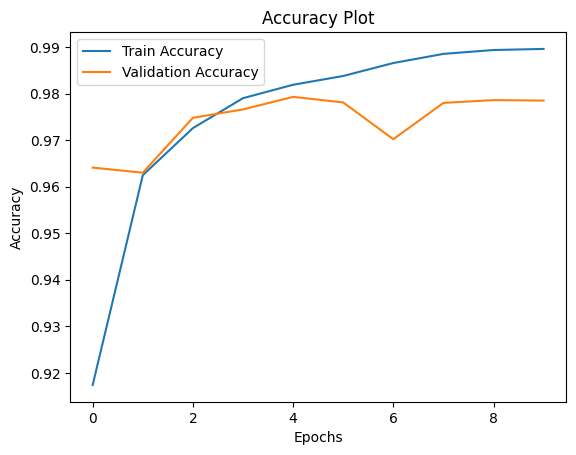

In [25]:
# 6. Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Plot')
plt.legend()
plt.show()

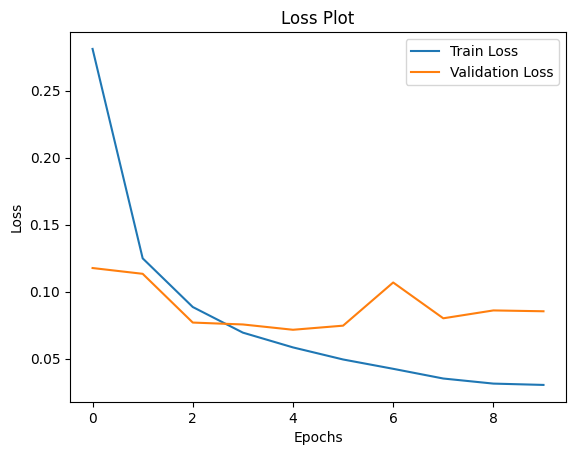

In [26]:
# 7. Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()

In [27]:
# 8. Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9785 - loss: 0.0853

Test Accuracy: 0.9785


In [29]:
# 9. Predictions (simple)
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
true_classes = y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


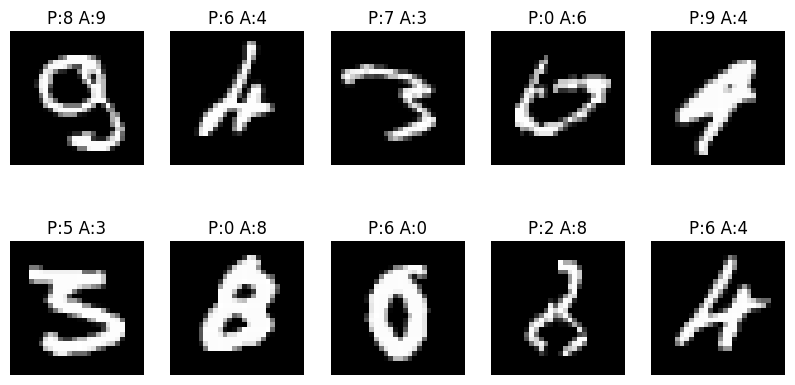

In [30]:
# Show some wrong predictions
wrong = np.where(pred_classes != true_classes)[0]

plt.figure(figsize=(10,5))
for i in range(10):
    idx = wrong[i]
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{pred_classes[idx]} A:{true_classes[idx]}")
    plt.axis('off')
plt.show()